#### Imports and setup

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from config import RAW_GAMES_PATH

#### Exploratory Data Analysis (EDA)

In [ ]:
# Load the processed dataset

df = pd.read_parquet(RAW_GAMES_PATH)


In [47]:
df.head()

,game_id,white_elo,black_elo,time_control,opening,result,moves,evals
0,https://lichess.org/oXyWZjvn,1802,1791,600+0,Sicilian Defense,1-0,"[e2e4, c7c5, g1f3, d7d6, b1c3, g8f6, f1c4, g7g...","[-32.0, 29.0, -27.0, 30.0, -29.0, 29.0, -19.0,..."
1,https://lichess.org/clKpvLl6,1270,1337,600+0,Scandinavian Defense,1-0,"[e2e4, d7d5, b1c3, d5d4, c3b5, c7c6, b5a3, g8f...","[-31.0, 72.0, 25.0, -18.0, 69.0, -18.0, 25.0, ..."
2,https://lichess.org/9mojvGgM,1743,1735,600+0,Pirc Defense,1-0,"[e2e4, d7d6, d2d4, g8f6, f1d3, g7g6, g1e2, f8g...","[-34.0, 55.0, -58.0, 39.0, -37.0, 64.0, -41.0,..."
3,https://lichess.org/cVGKAdOv,1822,1833,600+0,Philidor Defense: Exchange Variation,1/2-1/2,"[e2e4, e7e5, g1f3, d7d6, d2d4, e5d4, f3d4, g8f...","[-25.0, 31.0, -21.0, 20.0, -25.0, 33.0, -33.0,..."
4,https://lichess.org/3xkGeM1l,1195,1193,600+0,Elephant Gambit,1-0,"[e2e4, e7e5, g1f3, d7d5, e4d5, d8d5, b1c3, d5c...","[-16.0, 19.0, -34.0, 85.0, -89.0, 93.0, -80.0,..."


In [48]:
# Basic dataset overview

print(f"Dataset shape: {df.shape}")
print(df.info())
print(df.describe())

Dataset shape: (15000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   game_id       15000 non-null  str   
 1   white_elo     15000 non-null  int64 
 2   black_elo     15000 non-null  int64 
 3   time_control  15000 non-null  str   
 4   opening       15000 non-null  str   
 5   result        15000 non-null  str   
 6   moves         15000 non-null  object
 7   evals         15000 non-null  object
dtypes: int64(2), object(2), str(4)
memory usage: 1.9+ MB
None
         white_elo     black_elo
count  15000.00000  15000.000000
mean    1617.20680   1617.568133
std      264.47771    265.682356
min     1000.00000   1000.000000
25%     1427.00000   1427.000000
50%     1615.00000   1617.000000
75%     1802.00000   1802.000000
max     2497.00000   2496.000000


In [49]:
# Check for missing values

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
game_id         0
white_elo       0
black_elo       0
time_control    0
opening         0
result          0
moves           0
evals           0
dtype: int64


In [50]:
# Check data types and content of 'moves' and 'evals'

print(type(df['moves'][0]))
print(type(df['evals'][0]))
print(f"Moves in game 0: {len(df['moves'][0])}")
print(f"Evals in game 0: {len(df['evals'][0])}")
print(f"Sample evals: {df['evals'][0][:20]}")

print(f"Length of evals in game 0: {len(df['evals'][0])}")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Moves in game 0: 37
Evals in game 0: 37
Sample evals: [-32.  29. -27.  30. -29.  29. -19.  26. -10.   8.  56.  80.  77. -74.
  63. -56.  43. -25. 149. -49.]
Length of evals in game 0: 37


In [51]:
# Check for games with very few moves (which may have incomplete evals)

short_games = df[df['moves'].apply(len) < 25]
print(f"Games with fewer than 25 moves: {len(short_games)} ({len(short_games)/len(df)*100:.1f}%)")

Games with fewer than 25 moves: 444 (3.0%)


In [52]:
# Check for missing evals (None or NaN)

df['null_evals'] = df['evals'].apply(lambda x: sum(1 for e in x if e is None or (isinstance(e, float) and np.isnan(e))))
print(f"Games with any missing evals: {(df['null_evals'] > 0).sum()}")
print(f"Max missing evals in a single game: {df['null_evals'].max()}")

Games with any missing evals: 4845
Max missing evals in a single game: 48


In [53]:
# Where in the game are evals missing?

def missing_eval_positions(evals):
    return [i for i, e in enumerate(evals) if e is None or (isinstance(e, float) and np.isnan(e))]

df['missing_positions'] = df['evals'].apply(missing_eval_positions)

# Are any missing evals in the critical window (moves 15-25)?
df['missing_in_window'] = df['missing_positions'].apply(
    lambda positions: any(14 <= p <= 24 for p in positions)
)

print(f"Games with missing evals in critical window (moves 15-25): {df['missing_in_window'].sum()}")

Games with missing evals in critical window (moves 15-25): 98


In [54]:
# Filter out games with fewer than 25 moves (since they can't have a full eval window)

df = df[df['moves'].apply(len) >= 25]

In [55]:
# Filter out games with missing evals in the critical window

df = df[~df['missing_in_window']]

In [56]:
# Final dataset shape after filtering

print(f"Final dataset shape: {df.shape}")

Final dataset shape: (14541, 11)


In [57]:
# Check for missing values again

print("Missing values per column:")
print(df.isnull().sum())
print("Total NaN evals across all games: ")
print(df['evals'].apply(lambda x: sum(v != v for v in x)).sum())
game_lengths = df['moves'].apply(len)
print("Game length stats: ")
print(game_lengths.describe())

Missing values per column:
game_id              0
white_elo            0
black_elo            0
time_control         0
opening              0
result               0
moves                0
evals                0
null_evals           0
missing_positions    0
missing_in_window    0
dtype: int64
Total NaN evals across all games: 
5123
Game length stats: 
count    14541.000000
mean        66.948559
std         27.818981
min         25.000000
25%         47.000000
50%         61.000000
75%         80.000000
max        248.000000
Name: moves, dtype: float64


In [58]:
# Distribution of game lengths

print("\nTime control distributions")
print(df['time_control'].value_counts())


Time control distributions
time_control
600+0      8988
900+15     1365
900+0      1110
600+5       479
600+10      415
900+10      372
900+5       279
1800+0      251
600+2       182
600+3       168
600+8        96
900+3        84
900+2        78
600+1        68
600+4        59
600+15       55
1800+5       54
1800+30      54
900+8        52
1800+10      44
900+1        38
600+6        31
900+4        28
600+7        26
1800+15      23
900+7        19
900+6        13
1800+20      12
600+30       11
900+30        8
900+16        6
1800+3        6
1800+19       5
900+13        5
1800+60       5
1800+1        5
600+13        4
600+20        4
1800+25       4
600+9         4
600+12        3
1800+7        3
900+20        3
1800+2        3
900+11        3
900+12        2
900+45        2
1800+8        2
900+17        1
1800+35       1
600+45        1
900+40        1
1800+45       1
600+14        1
600+11        1
600+180       1
1800+6        1
600+60        1
Name: count, dtype: int64


In [59]:
# Distribution of results

print(df['result'].value_counts())

result
1-0        7068
0-1        6946
1/2-1/2     527
Name: count, dtype: int64


In [60]:
# Evals magnitude distribution

all_evals = np.concatenate(df['evals'].values)
print(f"Total eval values: {len(all_evals):,}")
print(f"Mate caps (+10000): {(all_evals == 10000).sum():,}")
print(f"Mate (-10000): {(all_evals == -10000).sum():,}")
print(f"% capped: {((all_evals == 10000) | (all_evals == -10000)).sum() / len(all_evals) * 100:.2f}%")

Total eval values: 973,499
Mate caps (+10000): 47,854
Mate (-10000): 35,615
% capped: 8.57%


#### Findings: Eval Magnitude Distribution

- Total eval values: 973,499
- ~4.94% of values are mate scores (±10000 sentinel values)
- These represent forced mate positions where Stockfish substitutes a sentinel instead of a centipawn score
- **Action (preprocessor):** Cap evals at ±1000 centipawns before computing deltas to avoid artificial swings


In [61]:
# Preliminary blunder rate

def has_blunder(evals, start=15, end=25, threshold=200, cap=1000):
    window = [max(-cap, min(cap, v)) for v in evals[start:end] if v == v]
    if len(window) < 2:
        return 0
    for offset in [0, 1]:
        side_evals = window[offset::2]
        for i in range(1, len(side_evals)):
            if side_evals[i-1] - side_evals[i] > threshold:
                return 1
    return 0


df['blunder_label'] = df['evals'].apply(has_blunder)
print(f"\nBlunder rate: {df['blunder_label'].mean():.2%}")
print(f"Blunder count: {df['blunder_label'].sum()} out of {len(df)} games")
print(f"No blunder count: {(df['blunder_label'] == 0).sum()} out of {len(df)} games")
print(f"No blunder rate: {(df['blunder_label'] == 0).mean():.2%}")


Blunder rate: 25.99%
Blunder count: 3779 out of 14541 games
No blunder count: 10762 out of 14541 games
No blunder rate: 74.01%


Total deltas: 939,294
Deltas > 200cp (blunder threshold): 47,652 (5.07%)
Deltas > 100cp: 86,566 (9.22%)
Deltas > 300cp: 30,147 (3.21%)


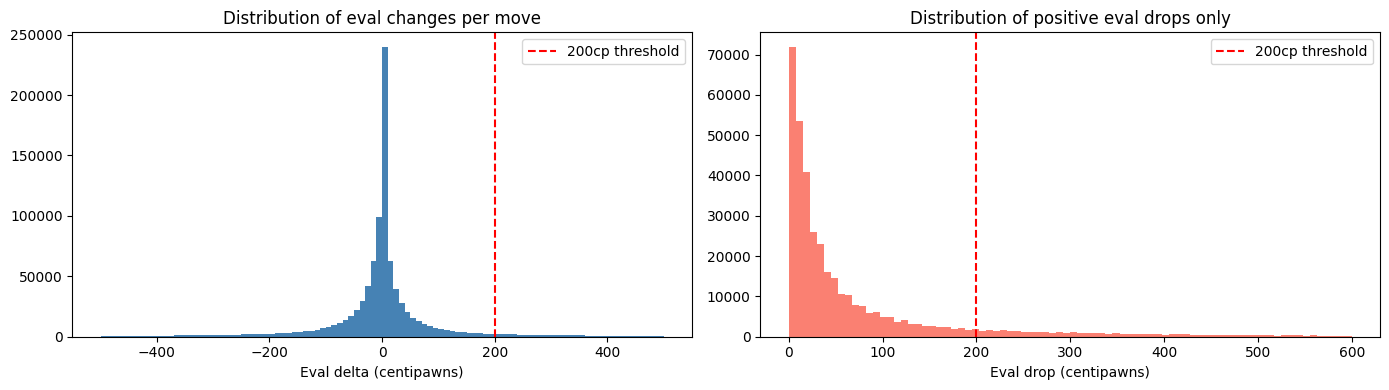

In [62]:
# Eval delta distribution (after capping) to justify blunder threshold

deltas = []
for evals in df['evals']:
    capped = [max(-1000, min(1000, v)) for v in evals if v == v]
    for offset in [0,1]:
        side = capped[offset::2]
        deltas.extend([side[i-1] - side[i] for i in range(1, len(side))])

deltas = np.array(deltas)
print(f"Total deltas: {len(deltas):,}")
print(f"Deltas > 200cp (blunder threshold): {(deltas > 200).sum():,} ({(deltas > 200).mean():.2%})")
print(f"Deltas > 100cp: {(deltas > 100).sum():,} ({(deltas > 100).mean():.2%})")
print(f"Deltas > 300cp: {(deltas > 300).sum():,} ({(deltas > 300).mean():.2%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(deltas, bins=100, range=(-500, 500), color='steelblue', edgecolor='none')
axes[0].axvline(200, color='red', linestyle='--', label='200cp threshold')
axes[0].set_xlabel('Eval delta (centipawns)')
axes[0].set_title('Distribution of eval changes per move')
axes[0].legend()

axes[1].hist(deltas[deltas > 0], bins=80, range=(0, 600), color='salmon', edgecolor='none')
axes[1].axvline(200, color='red', linestyle='--', label='200cp threshold')
axes[1].set_xlabel('Eval drop (centipawns)')
axes[1].set_title('Distribution of positive eval drops only')
axes[1].legend()

plt.tight_layout()
plt.show()

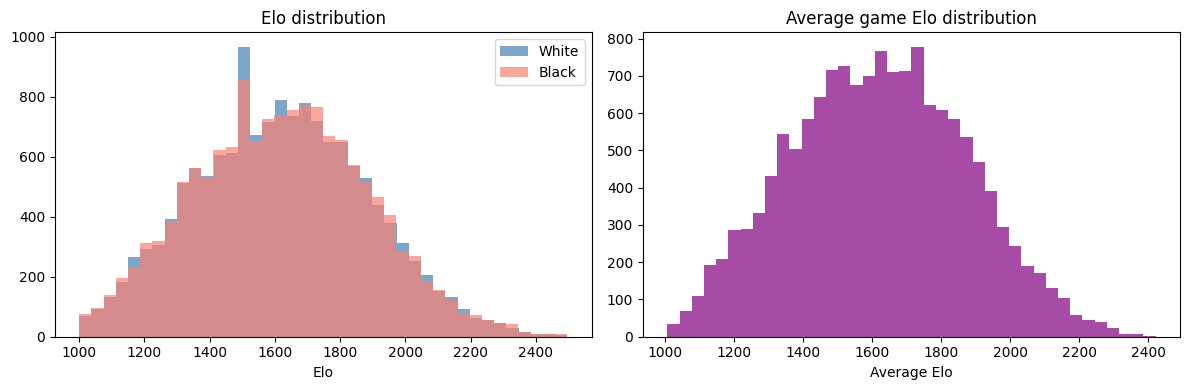

In [63]:
# Elo distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['white_elo'], bins=40, color='steelblue', edgecolor='none', alpha=0.7, label='White')
axes[0].hist(df['black_elo'], bins=40, color='salmon', edgecolor='none', alpha=0.7, label='Black')
axes[0].set_xlabel('Elo')
axes[0].set_title('Elo distribution')
axes[0].legend()

axes[1].hist((df['white_elo'] + df['black_elo']) / 2, bins=40, color='purple', edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Average Elo')
axes[1].set_title('Average game Elo distribution')

plt.tight_layout()
plt.show()


             blunder_rate  game_count
elo_bracket                          
1000-1200        0.529412         731
1200-1400        0.432804        2329
1400-1600        0.308661        3810
1600-1800        0.199356        4038
1800-2000        0.124431        2636
2000+            0.075226         997


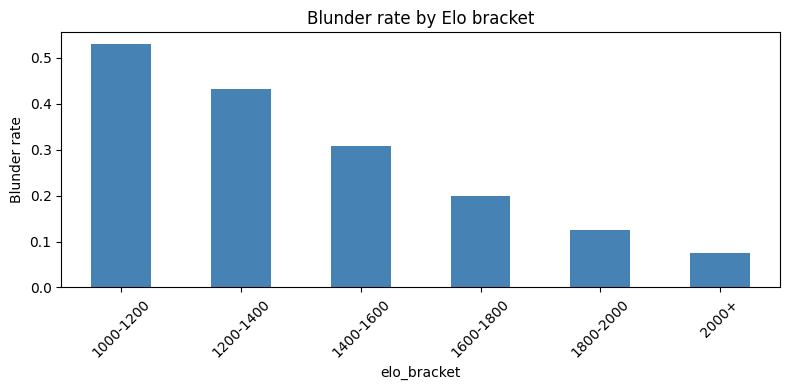

In [64]:
# Blunder rate by Elo bracket

df['avg_elo'] = (df['white_elo'] + df['black_elo']) / 2
df['elo_bracket'] = pd.cut(df['avg_elo'], bins=[1000, 1200, 1400, 1600, 1800, 2000, 2500],
                           labels=['1000-1200', '1200-1400', '1400-1600', '1600-1800', '1800-2000', '2000+'])

blunder_by_elo = df.groupby('elo_bracket', observed=True)['blunder_label'].agg(['mean', 'count'])
blunder_by_elo.columns = ['blunder_rate', 'game_count']
print(blunder_by_elo)

blunder_by_elo['blunder_rate'].plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.ylabel('Blunder rate')
plt.title('Blunder rate by Elo bracket')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
